<a href="https://colab.research.google.com/github/Arka12321/Interactive-a-c-for-Elliptical-Crack/blob/main/%CF%88(a_c%2C_%CE%B2)_for_Elliptical_Crack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

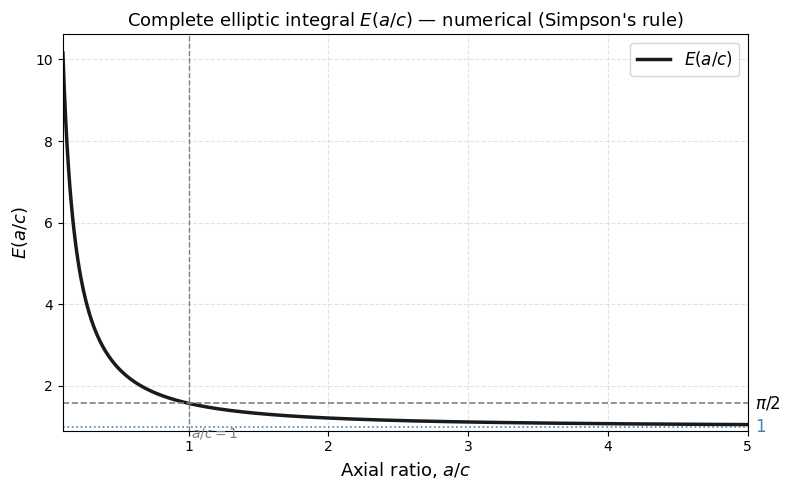

Done.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

def E_ac(ac, n=1000):
    """
    Numerical evaluation of the complete elliptic integral:

        E(a/c) = integral_0^{pi/2} [1 - (1 - c^2/a^2) * sin^2(Phi)]^{1/2} dPhi

    Method: composite Simpson's rule with n panels (n must be even).

    Notes:
      - For a/c = 1 (circle): coefficient = 0, integrand = 1, E = pi/2
      - For a/c > 1 (a > c): coefficient in (0,1), standard elliptic integral
      - For a/c < 1 (c > a): coefficient < 0, integrand > 1, E grows beyond pi/2
    """
    coeff = 1.0 - (1.0 / ac)**2
    phi   = np.linspace(0, np.pi/2, n + 1)
    f     = np.sqrt(1.0 - coeff * np.sin(phi)**2)
    h     = (np.pi / 2) / n
    E = (h / 3) * (f[0] + 4*np.sum(f[1:-1:2]) + 2*np.sum(f[2:-2:2]) + f[-1])
    return E


ac_vals = np.linspace(0.1, 5.0, 500)
E_vals  = np.array([E_ac(ac) for ac in ac_vals])

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ac_vals, E_vals, color="#1a1a1a", linewidth=2.5, label=r"$E(a/c)$")

ax.axhline(np.pi/2, color="gray", linestyle="--", linewidth=1.2)
ax.axvline(1.0,     color="gray", linestyle="--", linewidth=1.0)
ax.text(5.05, np.pi/2, r"$\pi/2$", va="center", fontsize=12)
ax.text(1.02, ax.get_ylim()[0] + 0.05, r"$a/c=1$", fontsize=10, color="gray", va="bottom")

ax.axhline(1.0, color="steelblue", linestyle=":", linewidth=1.2)
ax.text(5.05, 1.0, r"$1$", va="center", fontsize=12, color="steelblue")

ax.set_xlabel(r"Axial ratio, $a/c$", fontsize=13)
ax.set_ylabel(r"$E(a/c)$", fontsize=13)
ax.set_title(r"Complete elliptic integral $E(a/c)$ — numerical (Simpson's rule)", fontsize=13)
ax.set_xlim(0.1, 5.0)
ax.set_ylim(0.9, None)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(fontsize=12)

plt.tight_layout()

output_dir = "/mnt/user-data/outputs/"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "elliptic_integral_E.png"), dpi=150)
plt.show()
print("Done.")


In [8]:
def psi_vals(ac_vals, E_vals, beta_deg):
    beta = np.radians(beta_deg)
    ca = 1 / ac_vals
    inner = np.cos(beta)**2 + ca**2 * np.sin(beta)**2
    return np.sqrt(np.pi) * np.sqrt(inner) / E_vals


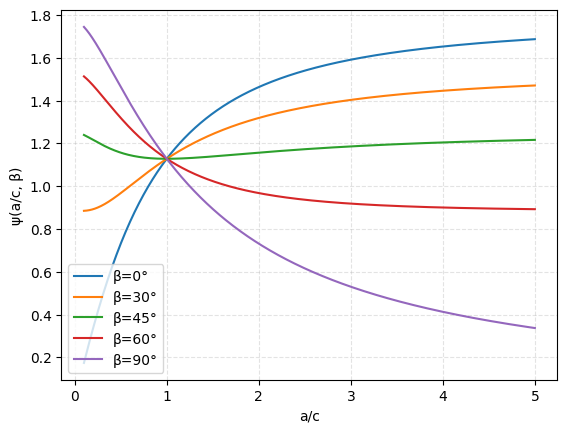

In [9]:
for beta in [0, 30, 45, 60, 90]:
    psi = psi_vals(ac_vals, E_vals, beta_deg=beta)
    plt.plot(ac_vals, psi, label=f"β={beta}°")

plt.xlabel("a/c")
plt.ylabel("ψ(a/c, β)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.35)
plt.show()

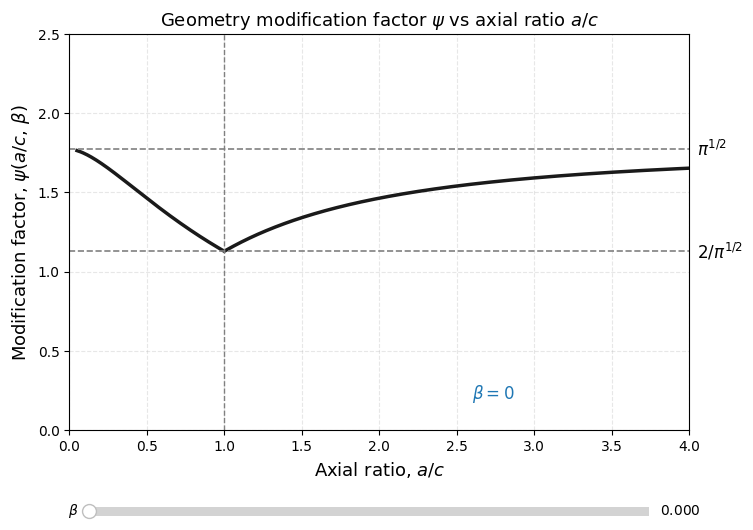

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.special import ellipe


def elliptic_E_vec(ac_array):
    """
    Analytical complete elliptic integral of the second kind E(k^2):
      k^2 = 1 - (c/a)^2  for a >= c  (ac >= 1)
      k^2 = 1 - (a/c)^2  for a <  c  (ac <  1)
    scipy.special.ellipe takes the parameter m = k^2.
    """
    k2 = np.where(ac_array >= 1,
                  1 - (1 / ac_array)**2,
                  1 - ac_array**2)
    return ellipe(k2)


def psi_vec(ac_array, E_array, beta):
    """
    psi(a/c, beta) = sqrt(pi) * [cos^2(beta) + (c/a)^2 * sin^2(beta)]^(1/2) / E(a/c)
    """
    ca = 1 / ac_array
    inner = np.cos(beta)**2 + ca**2 * np.sin(beta)**2
    return np.sqrt(np.pi) * np.sqrt(inner) / E_array


# --- Compute analytically (no precompute needed, it's instant) ---
ac_values = np.linspace(0.05, 4.0, 600)
E_values  = elliptic_E_vec(ac_values)

beta_init  = 0.0
psi_values = psi_vec(ac_values, E_values, beta_init)

fig, ax = plt.subplots(figsize=(8, 6))
plt.subplots_adjust(bottom=0.22)

(line,) = ax.plot(ac_values, psi_values, color="#1a1a1a", linewidth=2.5)

# Reference lines matching Fig 2.9
ax.axhline(np.sqrt(np.pi),   color="gray", linestyle="--", linewidth=1.2)
ax.axhline(2/np.sqrt(np.pi), color="gray", linestyle="--", linewidth=1.2)
ax.axvline(1.0,               color="gray", linestyle="--", linewidth=1.0)
ax.text(4.05, np.sqrt(np.pi),   r"$\pi^{1/2}$",   va="center", fontsize=12)
ax.text(4.05, 2/np.sqrt(np.pi), r"$2/\pi^{1/2}$", va="center", fontsize=12)

ax.set_xlabel("Axial ratio, $a/c$", fontsize=13)
ax.set_ylabel(r"Modification factor, $\psi(a/c,\,\beta)$", fontsize=13)
ax.set_title(r"Geometry modification factor $\psi$ vs axial ratio $a/c$", fontsize=13)
ax.set_xlim(0, 4)
ax.set_ylim(0, 2.5)
ax.grid(True, linestyle="--", alpha=0.3)

beta_text = ax.text(0.65, 0.08, r"$\beta = 0$",
                    transform=ax.transAxes, fontsize=12, color="#1f77b4")

# --- Slider ---
ax_slider = plt.axes([0.15, 0.07, 0.7, 0.03])
slider = Slider(ax=ax_slider, label=r"$\beta$",
                valmin=0, valmax=np.pi, valinit=beta_init,
                valstep=0.01, color="#1f77b4")


def beta_label(b):
    frac = b / np.pi
    if abs(frac) < 0.005:        return r"$\beta = 0$"
    if abs(frac - 0.25) < 0.008: return r"$\beta = \pi/4$"
    if abs(frac - 0.5)  < 0.008: return r"$\beta = \pi/2$"
    if abs(frac - 0.75) < 0.008: return r"$\beta = 3\pi/4$"
    if abs(frac - 1.0)  < 0.008: return r"$\beta = \pi$"
    return rf"$\beta = {frac:.2f}\pi$"


def update(val):
    b = slider.val
    line.set_ydata(psi_vec(ac_values, E_values, b))
    beta_text.set_text(beta_label(b))
    fig.canvas.draw_idle()


slider.on_changed(update)
plt.show()